<a href="https://colab.research.google.com/github/kiaraspreckley/KiaraSpreckley_DataScience_GenAI_Submission/blob/main/EDA_Seminar_Titanic_Data_Set_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

I need to start by loading the data. I am going to use Genai with the query

“please create a data frame from “titanic.csv”



In [ ]:
import pandas as pd

df = pd.read_csv("titanic.csv")
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


The data frame looks like it has been created properly. I will first check the number of rows and columns. I will type this code myself usinf the .shape code (as used in the GitHub example "2_05_Exploratory_Data_Analysis.ipynb"

In [ ]:
df.shape

(891, 12)

From this I can see there are 891 rows. I will now check if there is any missing values I will copy this code from "2_05_Exploratory_Data_Analysis.ipynb"

In [ ]:
df.isnull().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


From this I can tell there are 177 missing data points in the 'age category' and 687 in the cabin cetegory, and 2 in the embarked categoty. There are different approches I could take to deal with the missing values, I could  delete the rows effected, or drop the entire column. I will check what percentage of the columns have missing data to decide which approach to take. I will copy the code from "2_05_Exploratory_Data_Analysis.ipynb"

In [ ]:
# Percent of data which is not available
df.isnull().sum()/len(df) * 100

,0
PassengerId,0.000000
Survived,0.000000
Pclass,0.000000
Name,0.000000
Sex,0.000000
Age,19.865320
SibSp,0.000000
Parch,0.000000
Ticket,0.000000
Fare,0.000000


In the cabin cetegory, 77% of the rows have missing data, therefore I will drop this entire column. The embarked column only has 0.2% of rows with missing data, so I will just remove the rows effected.

For the age column, approximatley 20% has missing data, because I anticipate age being an important variable, I will just remove the effected rows. I will start with the AI prompt "Remove the column "Cabin" from the data set and show the new data frame"

In [ ]:
if 'Cabin' in df.columns:
    df.drop('Cabin', axis=1, inplace=True)
    print("Column 'Cabin' dropped successfully.")
else:
    print("Column 'Cabin' not found in DataFrame.")

Column 'Cabin' dropped successfully.


In [ ]:
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


Now, remove the rows with missing data from the "Age" and "Embarked" columns

In [ ]:
df.dropna(subset=['Age', 'Embarked'], inplace=True)
print(df.head())

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. William Henry    male  35.0      0   

   Parch            Ticket     Fare Embarked  
0      0         A/5 21171   7.2500        S  
1      0          PC 17599  71.2833        C  
2      0  STON/O2. 3101282   7.9250        S  
3      0            113803  53.1000        S  
4      0            373450   8.0500        S  


In [ ]:
display(df)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S
...,...,...,...,...,...,...,...,...,...,...,...
885,886,0,3,"Rice, Mrs. William (Margaret Norton)",female,39.0,0,5,382652,29.1250,Q
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C


I have now dropped the missing data rows, I will check that there is no more missing data using the same code as before

In [ ]:
# Percent of data which is not available
df.isnull().sum()/len(df) * 100

,0
PassengerId,0.0
Survived,0.0
Pclass,0.0
Name,0.0
Sex,0.0
Age,0.0
SibSp,0.0
Parch,0.0
Ticket,0.0
Fare,0.0


Good! There is no missing data, I will now check for any duplicates.



In [ ]:
print(f"Number of duplicated rows: {df.duplicated().sum()}")

Number of duplicated rows: 0


Good! There are no duplicated rows, if there were, I would have removed the duplicates.


With more time, I may want to convert the categorical variables into a numerical figure to allow me to draw more conclusions. I will do this for one variable. The "Sex" column has 2 categories, male and female. I will allocate the following numerical values to each category to use ordinal Encoding with scaled values: Male = 1
Female = 0

I will use the AI prompt: "Convert the data in the "sex" column to numerical values: female = 0, male = 1, and display the new dataframe in a table"

In [ ]:
df['Sex'] = df['Sex'].map({'female': 0, 'male': 1})
display(df.head())

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",1,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",0,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",0,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",0,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",1,35.0,0,0,373450,8.0500,S


This has worked, the "age" column now has numerical data coresponding to being male or female.  I will now get the descriptive statistics about this data using the code .describe()

In [ ]:
df.describe()


,PassengerId,Survived,Pclass,Sex,Age,SibSp,Parch,Fare
count,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000,712.000000
mean,448.589888,0.404494,2.240169,0.636236,29.642093,0.514045,0.432584,34.567251
std,258.683191,0.491139,0.836854,0.481420,14.492933,0.930692,0.854181,52.938648
min,1.000000,0.000000,1.000000,0.000000,0.420000,0.000000,0.000000,0.000000
25%,222.750000,0.000000,1.000000,0.000000,20.000000,0.000000,0.000000,8.050000
50%,445.000000,0.000000,2.000000,1.000000,28.000000,0.000000,0.000000,15.645850
75%,677.250000,1.000000,3.000000,1.000000,38.000000,1.000000,1.000000,33.000000
max,891.000000,1.000000,3.000000,1.000000,80.000000,5.000000,6.000000,512.329200


From this summary statistics, I can see the mean survival is (40%), that means an average of 40% of people survived, this seems accurate, as does the min and max being 0-1, this shows 0 correlates to not suriviving and 1 correlates to surviving. The class variable shows me there are 3 classes, (1,2,3). The avaerage sex being 0.63 indicates there were more males than females on the titanic. The age range shows me the oldest person was 80, yet the yongest person was 0.42 (i assume this refers to a baby who was only a few months old), most people however were middle aged. I can also tell the fare ranges from 512 to 0. however the 75 and 25% marks show me that most of the range is between 33 and 8 dollars or pounds. This may mean the 512 fare is an outlier. This is further validated as the 75% mark is 33 yet the mean is 34, this means there may be few high ticket prices skewing the data.

I will start by comparing the survival rate between males and females using the AI prompt "Show the average survival rate for "0" and "1" in the sex category"

In [ ]:
average_survival_by_sex = df.groupby('Sex')['Survived'].mean()
print(average_survival_by_sex)

Sex
0    0.752896
1    0.205298
Name: Survived, dtype: float64


I will use the AI prompt "Show this in a bar chart"

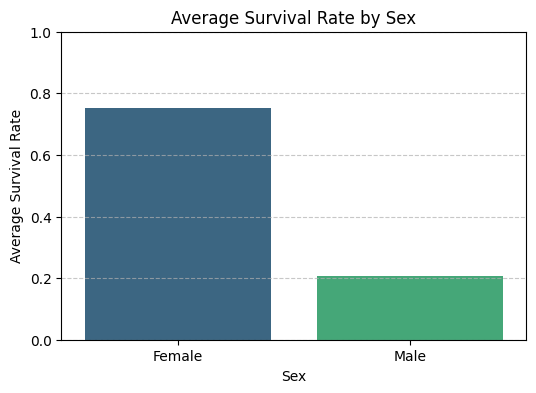

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Map the numerical sex values to labels for better readability
sex_labels = {0: 'Female', 1: 'Male'}
plot_data = average_survival_by_sex.rename(index=sex_labels)

plt.figure(figsize=(6, 4))
sns.barplot(x=plot_data.index, y=plot_data.values, hue=plot_data.index, palette='viridis', legend=False)
plt.title('Average Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Average Survival Rate')
plt.ylim(0, 1) # Survival rate is between 0 and 1
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

I can see that the survival rate for females is significantly higher, I would not have expected there to be any significant difference between the two. I wil now investigate if there is a difference in survival rates across the different classes. I will use the AI prompt, create a bar chart showing average survival rate with the "class" column

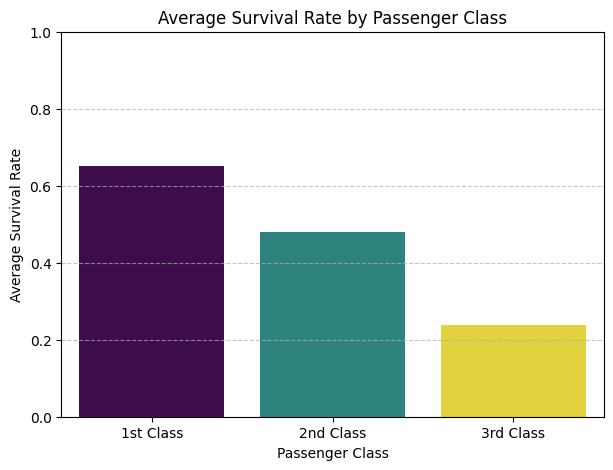

In [ ]:
average_survival_by_pclass = df.groupby('Pclass')['Survived'].mean()

plt.figure(figsize=(7, 5))
sns.barplot(x=average_survival_by_pclass.index, y=average_survival_by_pclass.values, hue=average_survival_by_pclass.index, palette='viridis', legend=False)
plt.title('Average Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Average Survival Rate')
plt.ylim(0, 1) # Survival rate is between 0 and 1
plt.xticks(ticks=[0, 1, 2], labels=['1st Class', '2nd Class', '3rd Class'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This is to be expected, that first class had a higher average survival rate than the lower classes. This indicates more wealthy people had a higher chance of surviving. I will now compare how many females and males were in each of the classes. I will use the AI prompt "Show in a bar chart the percentage of male and female passengers within each passenger class

In [ ]:
sex_distribution_by_pclass = df.groupby('Pclass')['Sex'].value_counts(normalize=True).unstack()
sex_distribution_by_pclass = sex_distribution_by_pclass * 100 # Convert to percentage

print("Percentage of Males and Females in Each Passenger Class:")
display(sex_distribution_by_pclass)

Percentage of Males and Females in Each Passenger Class:


Sex,0,1
Pclass,,
1,45.108696,54.891304
2,42.774566,57.225434
3,28.732394,71.267606


<Figure size 1000x600 with 0 Axes>

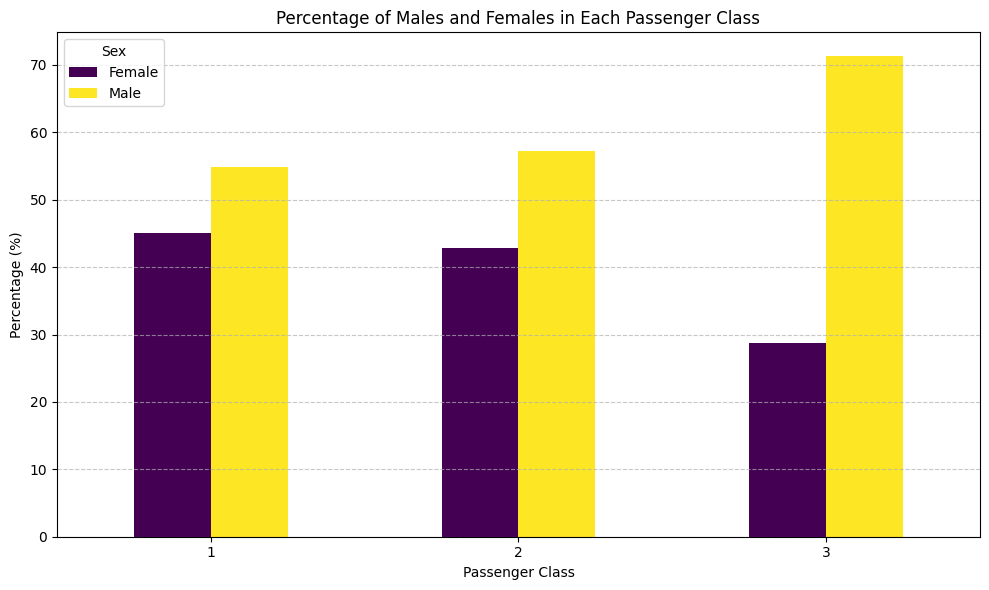

In [ ]:
plt.figure(figsize=(10, 6))
sex_distribution_by_pclass.plot(kind='bar', figsize=(10, 6), colormap='viridis')
plt.title('Percentage of Males and Females in Each Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Percentage (%)')
plt.xticks(rotation=0)
plt.legend(title='Sex', labels=['Female', 'Male'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

This is intresting, I would have expected for more females to be in 1st class given females had a higher survival rate. This tells me something else must have influenced more females than males surviving. However, this insight shows that there was significantly more males in 3rd class, who had the lowest survival rate. Therefore the combination of being Male AND being in 3rd Class may be a major factor driving the low overall survival rate for males.

In [ ]:
average_survival_by_parch = df.groupby('Parch')['Survived'].mean()
print(average_survival_by_parch)

Parch
0    0.354528
1    0.554545
2    0.573529
3    0.600000
4    0.000000
5    0.200000
6    0.000000
Name: Survived, dtype: float64


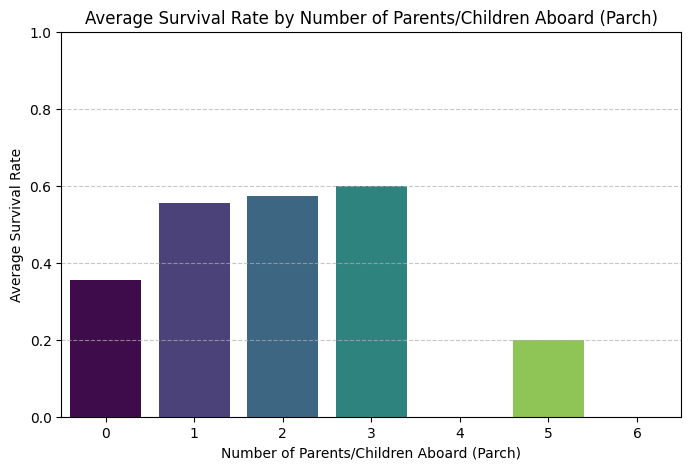

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(x=average_survival_by_parch.index, y=average_survival_by_parch.values, hue=average_survival_by_parch.index, palette='viridis', legend=False)
plt.title('Average Survival Rate by Number of Parents/Children Aboard (Parch)')
plt.xlabel('Number of Parents/Children Aboard (Parch)')
plt.ylabel('Average Survival Rate')
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This is intresting, it shows that in general, there is a trend for passengers with more children onboard having a higher survival rate. However, the lower survival rate for passengers with 5 kids having a lower survival rate seems to be an outlier here. I will check the number of passengers for each of these parch categories.

In [ ]:
parch_counts = df['Parch'].value_counts().sort_index()
print("Number of passengers in each 'Parch' category:")
display(parch_counts)

Number of passengers in each 'Parch' category:


,count
Parch,
0,519
1,110
2,68
3,5
4,4
5,5
6,1


Given that "Parch" 3 4 5 and 6 have such little data, I will draw conclusions based on the 0,1 and 2 categories.

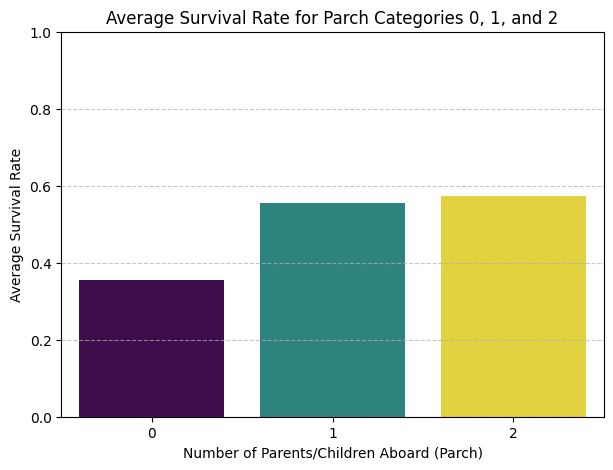

In [ ]:
parch_filtered_survival = average_survival_by_parch.loc[[0, 1, 2]]

plt.figure(figsize=(7, 5))
sns.barplot(x=parch_filtered_survival.index, y=parch_filtered_survival.values, hue=parch_filtered_survival.index, palette='viridis', legend=False)
plt.title('Average Survival Rate for Parch Categories 0, 1, and 2')
plt.xlabel('Number of Parents/Children Aboard (Parch)')
plt.ylabel('Average Survival Rate')
plt.ylim(0, 1)
plt.xticks(ticks=[0, 1, 2], labels=['0', '1', '2'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This shows me that if passengers had more children, their survival rate increased, I will now compare how the distribution of parch compared for sex.

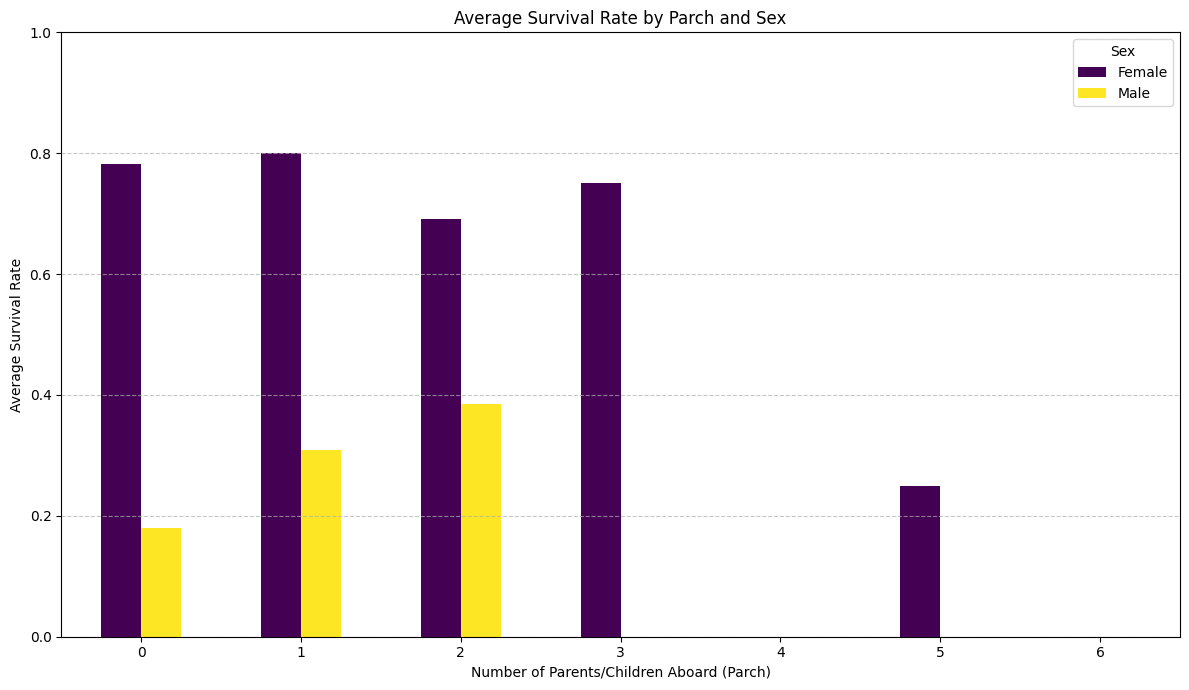

In [ ]:
survival_by_parch_sex = df.groupby(['Parch', 'Sex'])['Survived'].mean().unstack()

plt.figure(figsize=(12, 7))
survival_by_parch_sex.plot(kind='bar', colormap='viridis', ax=plt.gca())
plt.title('Average Survival Rate by Parch and Sex')
plt.xlabel('Number of Parents/Children Aboard (Parch)')
plt.ylabel('Average Survival Rate')
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title='Sex', labels=['Female', 'Male'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

"Calculate and display the percentage of males and females for each Parch category"

In [ ]:
gender_distribution_by_parch = df.groupby('Parch')['Sex'].value_counts(normalize=True).unstack()
gender_distribution_by_parch = gender_distribution_by_parch * 100 # Convert to percentage

print("Percentage of Males and Females in Each Parch Category:")
display(gender_distribution_by_parch)

Percentage of Males and Females in Each Parch Category:


Sex,0,1
Parch,,
0,29.094412,70.905588
1,50.000000,50.000000
2,61.764706,38.235294
3,80.000000,20.000000
4,50.000000,50.000000
5,80.000000,20.000000
6,100.000000,NaN


This shows me that more men had 0 parents/kids onboard, but more females has 2+ kids onboard. This suggests that one of the contributers to females having a higher survival rate is that they were more likley to have parch onboard, and thus, having more parch onboard correlated to having a higher survival rate. This makes sense in terms of how women with children would likley be saved first.

make a scatter plot of survival and age


/tmp/ipython-input-414338192.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['Age'], bins=20, kde=True, palette='viridis')


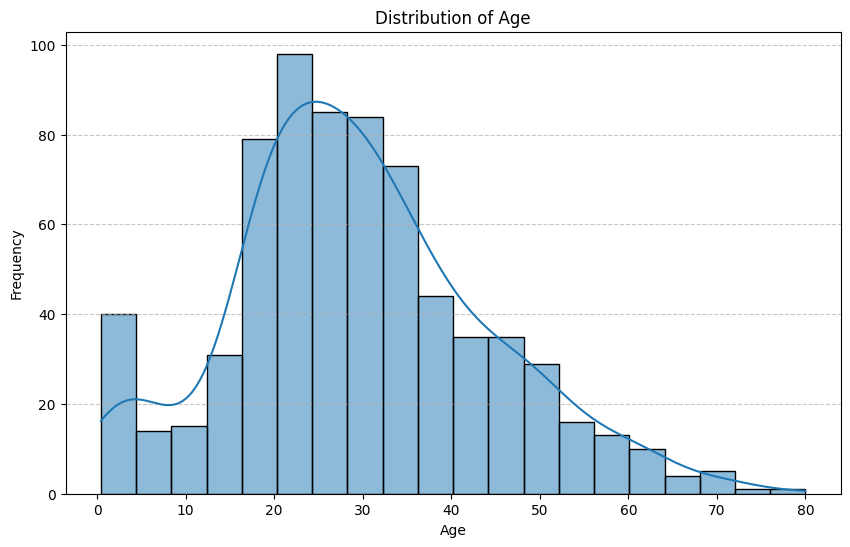

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'], bins=20, kde=True, palette='viridis')
plt.title('Distribution of Age')
plt.xlabel('Age')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

The distribution is centered around the 20s and 30s. The distribution is slightly right-skewed. This means the tail extends more to the right, though the bulk of the data is close to a normal distribution.

"Create a density plot of the 'Age' column, split by the 'Survived' column (0 and 1)."


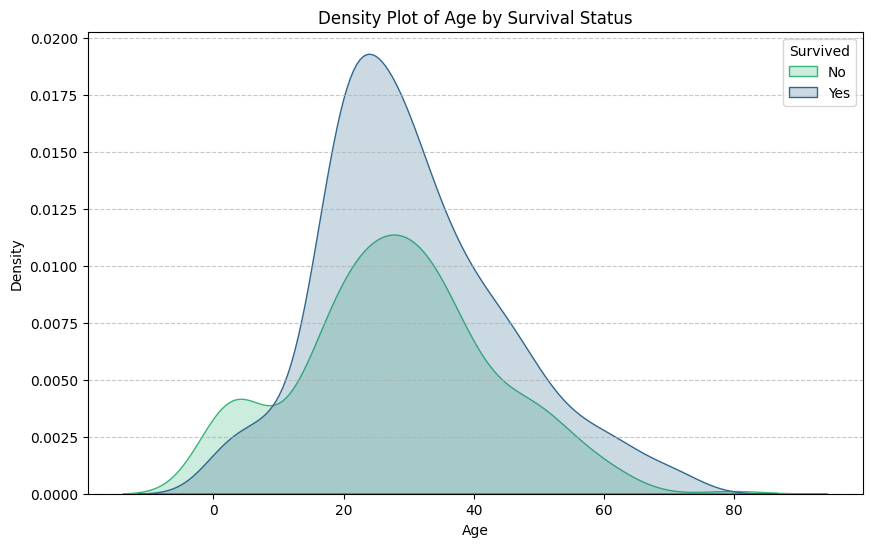

In [ ]:
plt.figure(figsize=(10, 6))
sns.kdeplot(x='Age', hue='Survived', data=df, fill=True, palette='viridis')
plt.title('Density Plot of Age by Survival Status')
plt.xlabel('Age')
plt.ylabel('Density')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

This shows me that there is a higher proportion of people that survived in the 0-10 years old range compared to those who did not survive.

calculate the average survival rate for each age, show this as a scatter plot


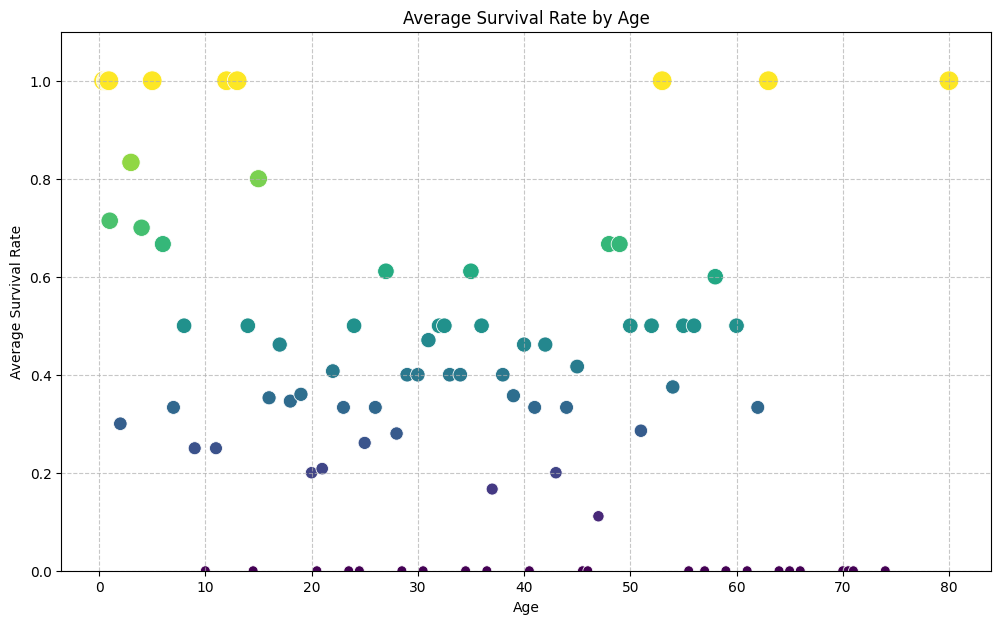

In [ ]:
average_survival_by_age = df.groupby('Age')['Survived'].mean().reset_index()

plt.figure(figsize=(12, 7))
sns.scatterplot(x='Age', y='Survived', data=average_survival_by_age, hue='Survived', size='Survived', sizes=(50, 200), palette='viridis', legend=False)
plt.title('Average Survival Rate by Age')
plt.xlabel('Age')
plt.ylabel('Average Survival Rate')
plt.ylim(0, 1.1) # Extend y-axis slightly to show all points
plt.grid(axis='both', linestyle='--', alpha=0.7)
plt.show()

this shows me there is no clear correlation between age and average survival rate. However we can see some type of a trend, in being that those with the average highest survival rates of 80-100% were either 15 and younger, or 50 and older. Suggesting the old and young were priorotised in being saved. This suggests most of those who did not survive came from middle aged indivisuals

Create a heatmap for the average survival rate for each combination of parch and siblings


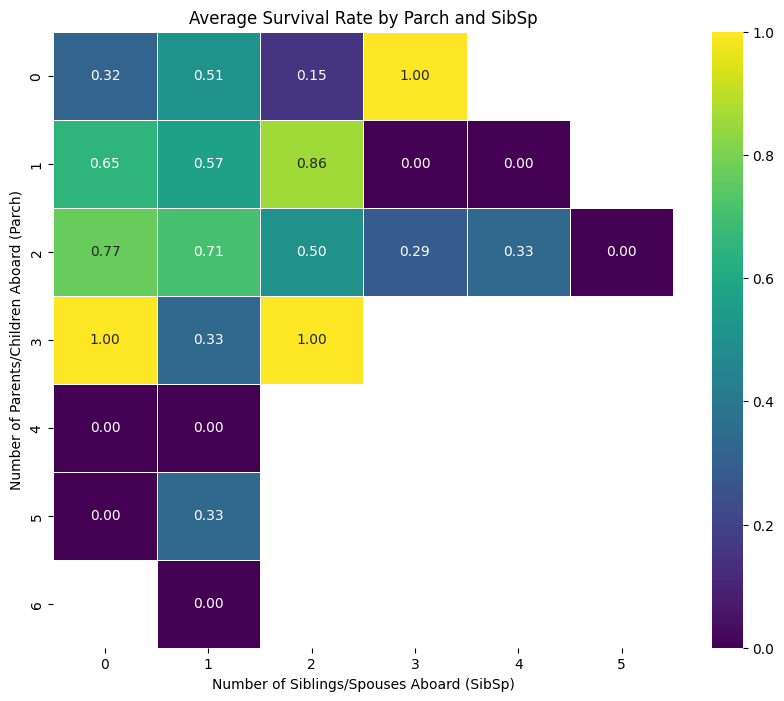

In [ ]:
survival_by_parch_sibsp = df.groupby(['Parch', 'SibSp'])['Survived'].mean().unstack()

plt.figure(figsize=(10, 8))
sns.heatmap(survival_by_parch_sibsp, annot=True, fmt=".2f", cmap='viridis', linewidths=.5)
plt.title('Average Survival Rate by Parch and SibSp')
plt.xlabel('Number of Siblings/Spouses Aboard (SibSp)')
plt.ylabel('Number of Parents/Children Aboard (Parch)')
plt.show()

the 500 fare is probably an outlier

I will now compare survival rate to age

# Task
Create a violin plot to visualize the distribution of 'Fare' across different 'Pclass' categories, with 'Survived' as a hue, to observe how fare and class relate to survival, and then provide insights from the visualization regarding the relationship between fare, passenger class, and survival rate.

## Compare Fare, Class, and Survival Rate

### Subtask:
Create a violin plot to visualize the distribution of 'Fare' across different 'Pclass' categories, with 'Survived' as a hue, to observe how fare and class relate to survival.


**Reasoning**:
To visualize the distribution of 'Fare' across different 'Pclass' categories, with 'Survived' as a hue, I will create a violin plot using `seaborn.violinplot` as instructed. I will also set the title, axis labels, and y-axis limits to ensure a clear and focused visualization.



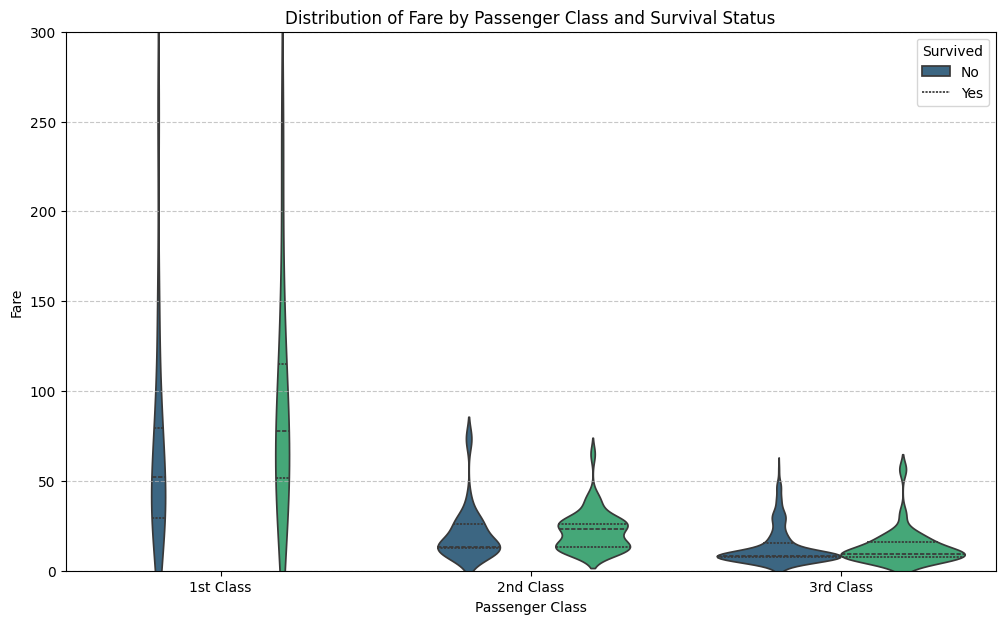

In [ ]:
plt.figure(figsize=(12, 7))
sns.violinplot(x='Pclass', y='Fare', hue='Survived', data=df, palette='viridis', inner='quartile')
plt.title('Distribution of Fare by Passenger Class and Survival Status')
plt.xlabel('Passenger Class')
plt.ylabel('Fare')
plt.ylim(0, 300) # Set y-axis limit to focus on the majority of the data
plt.xticks(ticks=[0, 1, 2], labels=['1st Class', '2nd Class', '3rd Class'])
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend(title='Survived', labels=['No', 'Yes'])
plt.show()

/tmp/ipython-input-297419890.py:2: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  sns.histplot(df['Fare'], bins=30, kde=True, palette='viridis')


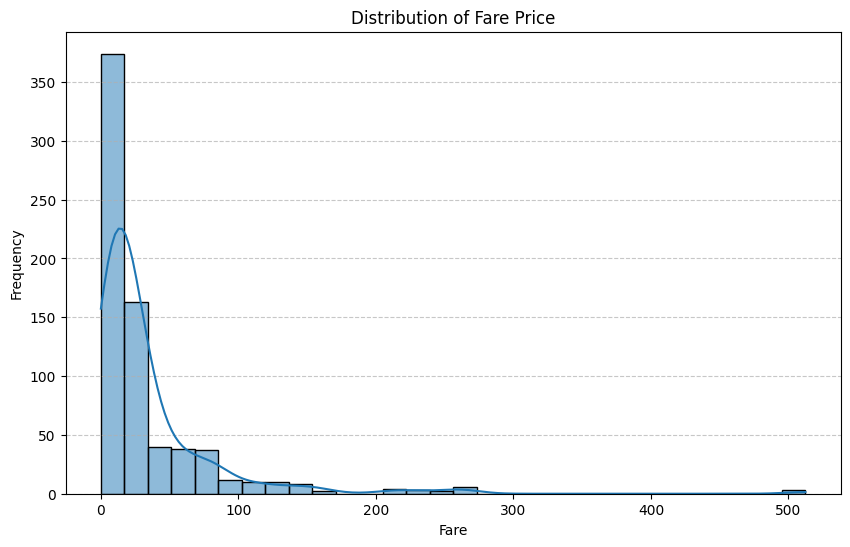

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Fare'], bins=30, kde=True, palette='viridis')
plt.title('Distribution of Fare Price')
plt.xlabel('Fare')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

This histogram of fare price suggests the price of 500 to be an outlier. With more time and in the real world, this would need to be investigated as to whether it is an anomaly or an error, and a decision would be made as to if the outlier should be removed from the data set. For now, I will just acknowledge that this outlier has likely thrown off the mean average for this category.